# Cross-Dataset Model Analysis (H-CAST Style)

This notebook keeps the same style as `hcast_analysis.ipynb`, but compares **models** across **datasets**.

It includes:
- per-dataset validation curves (`FPA`, `wAP`, `TICE`),
- per-dataset training loss curves,
- per-level validation accuracy curves,
- final test tables and quick summaries.

In [56]:
from pathlib import Path
import json
import re
from collections import defaultdict

import numpy as np
import yaml
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


def resolve_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / 'outputs').exists() and (candidate / 'configs').exists():
            return candidate
    return cwd


PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = PROJECT_ROOT / 'outputs'
print(f'Using project root: {PROJECT_ROOT}')

Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [57]:
_ACC_LEVEL_PATTERN = re.compile(r'^acc_level_(\d+)$')
_ACC_LEVEL_TOPDOWN_PATTERN = re.compile(r'^acc_level_topdown_(\d+)$')
_ACC_LEVEL_INDEPENDENT_PATTERN = re.compile(r'^acc_level_independent_(\d+)$')
_LOSS_LEVEL_PATTERN = re.compile(r'^loss_level_(\d+)$')

_DATASET_ALIASES = {
    'cifar100': 'cifar-100',
    'cifar-100': 'cifar-100',
    'cub': 'cub-200-2011',
    'cub200': 'cub-200-2011',
    'cub-200': 'cub-200-2011',
    'cub-200-2011': 'cub-200-2011',
    'aircraft': 'fgvc-aircraft',
    'fgvc-aircraft': 'fgvc-aircraft',
    'inat': 'inat21-mini',
    'inat21-mini': 'inat21-mini',
    'inat21_mini': 'inat21-mini',
}

_DATASET_DISPLAY = {
    'cifar-100': 'CIFAR-100',
    'cub-200-2011': 'CUB-200-2011',
    'fgvc-aircraft': 'FGVC-Aircraft',
    'inat21-mini': 'iNat21-Mini',
}

_MODEL_ALIASES = {
    'hcast': 'hcast',
    'hrn': 'hrn',
    'ht_capsnet': 'ht_capsnet',
    'htcapsnet': 'ht_capsnet',
    'capsnet': 'ht_capsnet',
}

_MODEL_DISPLAY = {
    'hcast': 'H-CAST',
    'hrn': 'HRN',
    'ht_capsnet': 'HT-CapsNet',
}

_MODEL_COLORS = {
    'hcast': '#1f77b4',
    'hrn': '#ff7f0e',
    'ht_capsnet': '#2ca02c',
}


def _as_float_dict(metrics):
    out = {}
    if not isinstance(metrics, dict):
        return out
    for key, value in metrics.items():
        try:
            out[str(key)] = float(value)
        except (TypeError, ValueError):
            continue
    return out


def normalize_metrics(metrics):
    out = _as_float_dict(metrics)

    if 'weighted_ap_topdown' not in out:
        if 'weighted_ap' in out:
            out['weighted_ap_topdown'] = out['weighted_ap']
        elif 'weighted_ap_independent' in out:
            out['weighted_ap_topdown'] = out['weighted_ap_independent']
    if 'weighted_ap_independent' not in out and 'weighted_ap_topdown' in out:
        out['weighted_ap_independent'] = out['weighted_ap_topdown']

    if 'fpa_topdown' not in out:
        if 'fpa' in out:
            out['fpa_topdown'] = out['fpa']
        elif 'fpa_independent' in out:
            out['fpa_topdown'] = out['fpa_independent']
    if 'fpa_independent' not in out and 'fpa_topdown' in out:
        out['fpa_independent'] = out['fpa_topdown']

    if 'tice_topdown' not in out:
        if 'tice' in out:
            out['tice_topdown'] = out['tice']
        elif 'tice_independent' in out:
            out['tice_topdown'] = out['tice_independent']
    if 'tice_independent' not in out and 'tice_topdown' in out:
        out['tice_independent'] = out['tice_topdown']

    if 'ahd_topdown' not in out:
        if 'ahd' in out:
            out['ahd_topdown'] = out['ahd']
        elif 'ahd_independent' in out:
            out['ahd_topdown'] = out['ahd_independent']
    if 'ahd_independent' not in out and 'ahd_topdown' in out:
        out['ahd_independent'] = out['ahd_topdown']

    for key, value in list(out.items()):
        match = _ACC_LEVEL_PATTERN.match(key)
        if match:
            level_idx = int(match.group(1))
            out.setdefault(f'acc_level_independent_{level_idx}', value)
            out.setdefault(f'acc_level_topdown_{level_idx}', value)

    level_ids = set()
    for key in list(out.keys()):
        match = _ACC_LEVEL_TOPDOWN_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))
            continue
        match = _ACC_LEVEL_INDEPENDENT_PATTERN.match(key)
        if match:
            level_ids.add(int(match.group(1)))

    for level_idx in level_ids:
        topdown_key = f'acc_level_topdown_{level_idx}'
        independent_key = f'acc_level_independent_{level_idx}'
        if topdown_key not in out and independent_key in out:
            out[topdown_key] = out[independent_key]
        if independent_key not in out and topdown_key in out:
            out[independent_key] = out[topdown_key]

    return out


def load_jsonl_events(path):
    events = []
    with Path(path).open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                events.append(json.loads(line))
    return events


def load_yaml(path):
    with Path(path).open('r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def canonical_dataset_name(name):
    if name is None:
        return 'unknown-dataset'
    key = str(name).strip().lower().replace(' ', '').replace('_', '-')
    return _DATASET_ALIASES.get(key, key)


def dataset_display_name(name):
    canonical = canonical_dataset_name(name)
    return _DATASET_DISPLAY.get(canonical, canonical)


def canonical_model_name(name):
    if name is None:
        return 'unknown-model'
    key = str(name).strip().lower().replace(' ', '').replace('-', '_')
    return _MODEL_ALIASES.get(key, key)


def model_display_name(name):
    canonical = canonical_model_name(name)
    return _MODEL_DISPLAY.get(canonical, canonical)


def metric_for_best(metrics):
    m = normalize_metrics(metrics)

    has_fpa = 'fpa_topdown' in m
    has_tice = 'tice_topdown' in m
    has_wap = 'weighted_ap_topdown' in m

    if has_fpa or has_tice or has_wap:
        fpa = float(m.get('fpa_topdown', 0.0))
        neg_tice = -float(m.get('tice_topdown', 1.0))
        wap = float(m.get('weighted_ap_topdown', 0.0))
        return float(fpa + 1e-3 * neg_tice + 1e-6 * wap)

    topdown_keys = [
        key
        for key in m
        if key.startswith('acc_level_topdown_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    independent_keys = [
        key
        for key in m
        if key.startswith('acc_level_independent_') and key.rsplit('_', 1)[-1].isdigit()
    ]
    deepest = topdown_keys or independent_keys
    if not deepest:
        return float(m.get('fpa_topdown', 0.0))

    deepest_key = max(deepest, key=lambda key: int(key.rsplit('_', 1)[-1]))
    primary = float(m.get(deepest_key, 0.0))
    tie = float(m.get('fpa_topdown', 0.0))
    return float(primary + 1e-3 * tie)


def parse_run(run_dir):
    run_path = Path(run_dir)

    cfg = {}
    cfg_path = run_path / 'config_resolved.yaml'
    if cfg_path.exists():
        cfg = load_yaml(cfg_path) or {}

    events = []
    log_path = run_path / 'run_log.jsonl'
    if log_path.exists():
        events = load_jsonl_events(log_path)

    epoch_events = [event for event in events if event.get('event') == 'epoch']
    for event in epoch_events:
        event['train_metrics_norm'] = normalize_metrics(event.get('train_metrics', {}))
        event['val_metrics_norm'] = normalize_metrics(event.get('val_metrics', {}))
        event['rank_score'] = metric_for_best(event['val_metrics_norm'])

    test_event = {}
    test_events = [event for event in events if event.get('event') == 'test']
    if test_events:
        test_event = test_events[-1]

    test_metrics = normalize_metrics(test_event.get('test_metrics', {}))
    test_yaml_path = run_path / 'test_metrics.yaml'
    if test_yaml_path.exists():
        test_metrics_yaml = load_yaml(test_yaml_path) or {}
        yaml_metrics = normalize_metrics(test_metrics_yaml.get('test_metrics', {}))
        if yaml_metrics:
            test_metrics = {**yaml_metrics, **test_metrics}

    best_epoch_event = None
    if epoch_events:
        best_idx = int(np.argmax([event['rank_score'] for event in epoch_events]))
        best_epoch_event = epoch_events[best_idx]

    model_raw = cfg.get('model', {}).get('name')
    dataset_raw = cfg.get('dataset', {}).get('name')
    model_name = canonical_model_name(model_raw)

    return {
        'run_dir': run_path,
        'run_name': run_path.name,
        'config': cfg,
        'events': events,
        'epoch_events': epoch_events,
        'test_event': test_event,
        'test_metrics': test_metrics,
        'best_epoch_event': best_epoch_event,
        'level_names': list(cfg.get('dataset', {}).get('levels', [])),
        'dataset_name': canonical_dataset_name(dataset_raw),
        'dataset_label': dataset_display_name(dataset_raw),
        'model_name': model_name,
        'model_label': model_display_name(model_raw),
        'color': _MODEL_COLORS.get(model_name, None),
    }


def discover_run_dirs(output_root, manual_run_dirs=None, auto_discover=True):
    manual_run_dirs = manual_run_dirs or []
    out = []
    for item in manual_run_dirs:
        p = Path(item)
        if p.exists() and p.is_dir():
            out.append(p)

    if auto_discover:
        root = Path(output_root)
        if root.exists():
            out.extend(sorted({p.parent for p in root.rglob('run_log.jsonl')}))

    return sorted({p.resolve() for p in out})


def selection_score(run_data, strategy='best_val_rank'):
    if strategy == 'best_val_rank':
        best = run_data.get('best_epoch_event')
        if best is None:
            return -np.inf
        return float(best.get('rank_score', -np.inf))

    if strategy == 'best_test_fpa_topdown':
        return float(run_data.get('test_metrics', {}).get('fpa_topdown', -np.inf))

    if strategy == 'latest_modified':
        try:
            return float(run_data['run_dir'].stat().st_mtime)
        except FileNotFoundError:
            return -np.inf

    raise ValueError(f'Unknown selection strategy: {strategy}')


def select_representative_runs(runs, strategy='best_val_rank'):
    grouped = defaultdict(list)
    for run in runs:
        grouped[(run['dataset_name'], run['model_name'])].append(run)

    selected = []
    dropped = []
    for key, group in grouped.items():
        scores = [selection_score(run, strategy) for run in group]
        winner_idx = int(np.argmax(scores))
        selected.append(group[winner_idx])
        for idx, run in enumerate(group):
            if idx != winner_idx:
                dropped.append((run, scores[idx], scores[winner_idx]))

    return sorted(selected, key=lambda x: (x['dataset_name'], x['model_name'], x['run_name'])), dropped


def get_metric_series(epoch_events, metric_key, source='val_metrics_norm'):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event.get(source, {}).get(metric_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


def get_train_loss_series(epoch_events, loss_key):
    epochs = [int(event['epoch']) for event in epoch_events]
    values = [float(event.get('train_losses', {}).get(loss_key, np.nan)) for event in epoch_events]
    return np.array(epochs, dtype=np.int32), np.array(values, dtype=np.float64)


def get_level_label(level_idx, run_data):
    names = run_data.get('level_names') or []
    if level_idx < len(names):
        return str(names[level_idx])
    return f'L{level_idx}'


def ordered(items, preferred_order):
    item_set = set(items)
    ordered_pref = [x for x in preferred_order if x in item_set]
    rest = sorted([x for x in item_set if x not in ordered_pref])
    return ordered_pref + rest


def fmt_pct(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{100.0 * x:.2f}%'


def fmt_delta_pp(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{100.0 * x:.2f} pp'


def fmt_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    return f'{x:.3f}'


def fmt_delta_edges(x):
    if x is None or not np.isfinite(x):
        return 'n/a'
    sign = '+' if x >= 0 else ''
    return f'{sign}{x:.3f}'


In [58]:
# -------- Configuration --------
OUTPUT_ROOT = OUTPUTS_ROOT
AUTO_DISCOVER = True
MANUAL_RUN_DIRS = []  # Example: [OUTPUTS_ROOT / 'hcast_cifar100', OUTPUTS_ROOT / 'hrn_cifar100']

# Optional filters (leave empty = keep everything)
INCLUDE_MODELS = []   # hcast, hrn, ht_capsnet
INCLUDE_DATASETS = [] # cifar-100, cub-200-2011, fgvc-aircraft, inat21-mini
INCLUDE_RUN_NAME_SUBSTRINGS = []
EXCLUDE_RUN_NAME_SUBSTRINGS = ['design', 'warmup']

# Run selection when multiple runs exist for same (dataset, model)
SELECT_ONE_RUN_PER_MODEL_DATASET = True
SELECTION_STRATEGY = 'best_val_rank'  # best_val_rank | best_test_fpa_topdown | latest_modified

PREFERRED_DATASET_ORDER = ['cifar-100', 'cub-200-2011', 'fgvc-aircraft', 'inat21-mini']
PREFERRED_MODEL_ORDER = ['hcast', 'hrn', 'ht_capsnet']

In [59]:
candidate_run_dirs = discover_run_dirs(OUTPUT_ROOT, MANUAL_RUN_DIRS, AUTO_DISCOVER)
print(f'Candidate run directories: {len(candidate_run_dirs)}')

parsed_runs = []
parse_errors = []
for run_dir in candidate_run_dirs:
    try:
        parsed_runs.append(parse_run(run_dir))
    except Exception as exc:
        parse_errors.append((str(run_dir), str(exc)))

print(f'Parsed runs: {len(parsed_runs)}')
if parse_errors:
    print('Parse errors:')
    for run_dir, err in parse_errors:
        print(f'  - {run_dir}: {err}')

include_models_norm = {canonical_model_name(x) for x in INCLUDE_MODELS}
include_datasets_norm = {canonical_dataset_name(x) for x in INCLUDE_DATASETS}
include_tokens = [token.lower() for token in INCLUDE_RUN_NAME_SUBSTRINGS]
exclude_tokens = [token.lower() for token in EXCLUDE_RUN_NAME_SUBSTRINGS]

filtered_runs = []
for run in parsed_runs:
    run_name_l = run['run_name'].lower()

    if include_models_norm and run['model_name'] not in include_models_norm:
        continue
    if include_datasets_norm and run['dataset_name'] not in include_datasets_norm:
        continue
    if include_tokens and not any(token in run_name_l for token in include_tokens):
        continue
    if exclude_tokens and any(token in run_name_l for token in exclude_tokens):
        continue

    filtered_runs.append(run)

print(f'Filtered runs: {len(filtered_runs)}')

runs_for_analysis = filtered_runs
dropped_runs = []
if SELECT_ONE_RUN_PER_MODEL_DATASET:
    runs_for_analysis, dropped_runs = select_representative_runs(filtered_runs, strategy=SELECTION_STRATEGY)

if not runs_for_analysis:
    raise ValueError('No runs after filtering/selection. Update configuration and rerun.')

if dropped_runs:
    print(f'Representative selection dropped {len(dropped_runs)} run(s).')

# fill fallback colors from tab10 if a model color is unknown
unknown_models = sorted({run['model_name'] for run in runs_for_analysis if run.get('color') is None})
if unknown_models:
    cmap = plt.get_cmap('tab10')
    for idx, model_name in enumerate(unknown_models):
        _MODEL_COLORS[model_name] = cmap(idx % 10)
    for run in runs_for_analysis:
        if run.get('color') is None:
            run['color'] = _MODEL_COLORS[run['model_name']]

dataset_keys = ordered([run['dataset_name'] for run in runs_for_analysis], PREFERRED_DATASET_ORDER)
model_keys = ordered([run['model_name'] for run in runs_for_analysis], PREFERRED_MODEL_ORDER)

runs_by_dataset = {d: [] for d in dataset_keys}
for run in runs_for_analysis:
    runs_by_dataset[run['dataset_name']].append(run)

for d in dataset_keys:
    runs_by_dataset[d] = sorted(
        runs_by_dataset[d],
        key=lambda r: (PREFERRED_MODEL_ORDER.index(r['model_name']) if r['model_name'] in PREFERRED_MODEL_ORDER else 999, r['model_name'], r['run_name'])
    )

print('\nSelected runs')
print('-------------')
for d in dataset_keys:
    print(f"{dataset_display_name(d)}")
    for run in runs_by_dataset[d]:
        best_event = run['best_epoch_event']
        best_epoch = best_event['epoch'] if best_event is not None else None
        best_score = best_event['rank_score'] if best_event is not None else np.nan
        test_fpa = run['test_metrics'].get('fpa_topdown', np.nan)
        print(
            f"  - {run['model_label']:<12} | run={run['run_name']:<35} "
            f"| best_epoch={str(best_epoch):<4} | best_score={best_score:.4f} | test_FPA_td={fmt_pct(test_fpa)}"
        )

Candidate run directories: 7
Parsed runs: 7
Filtered runs: 5

Selected runs
-------------
CIFAR-100
  - H-CAST       | run=hcast_cifar100                      | best_epoch=96   | best_score=0.7497 | test_FPA_td=73.81%
  - HT-CapsNet   | run=capsnet_cifar100                    | best_epoch=4    | best_score=0.0221 | test_FPA_td=2.05%
CUB-200-2011
  - H-CAST       | run=hcast_cub200                        | best_epoch=99   | best_score=0.8115 | test_FPA_td=81.12%
  - HT-CapsNet   | run=capsnet_cub200                      | best_epoch=10   | best_score=0.0084 | test_FPA_td=21.38%
FGVC-Aircraft
  - H-CAST       | run=hcast_aircraft                      | best_epoch=89   | best_score=0.7358 | test_FPA_td=72.00%


## Validation Metrics Curves (Per Dataset)

Interpretation note:
- For `FPA` and `wAP`, higher is better.
- For `TICE`, lower is better.
- Solid lines are top-down metrics; dashed lines are independent metrics.

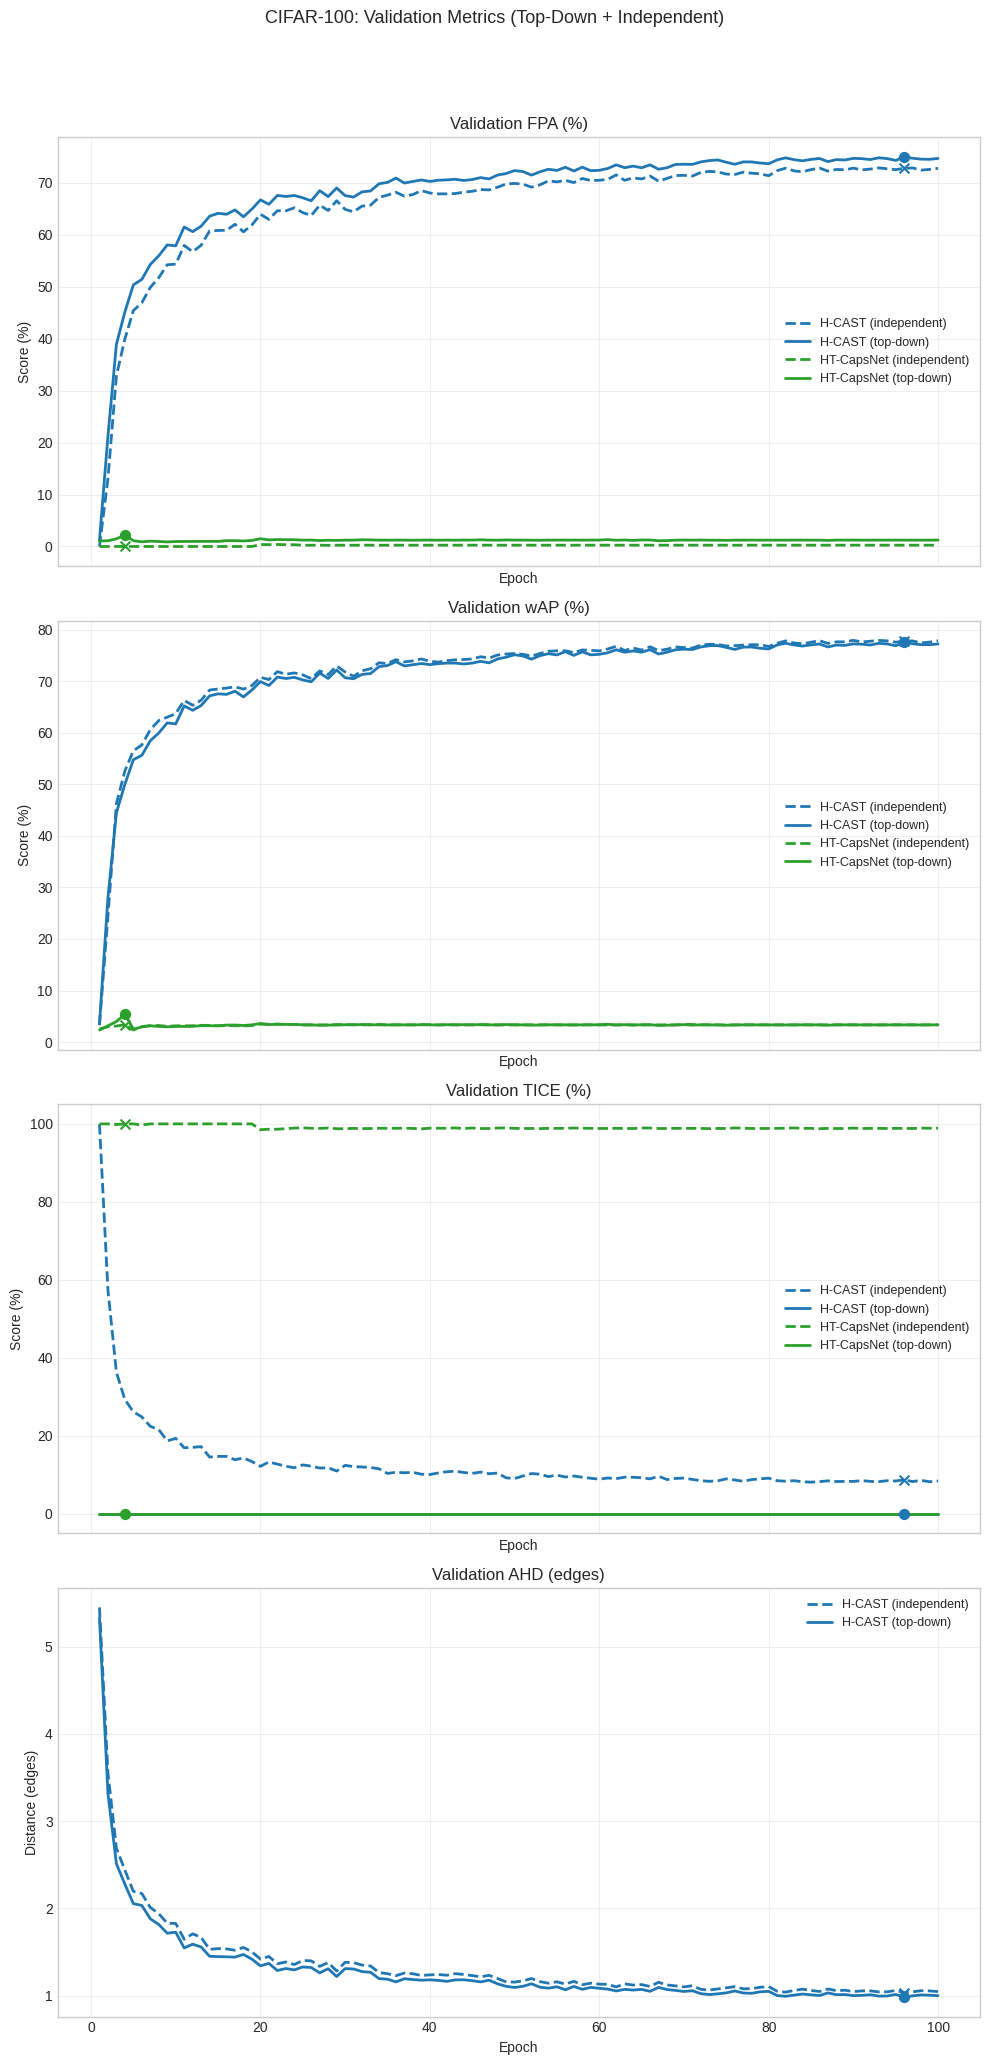

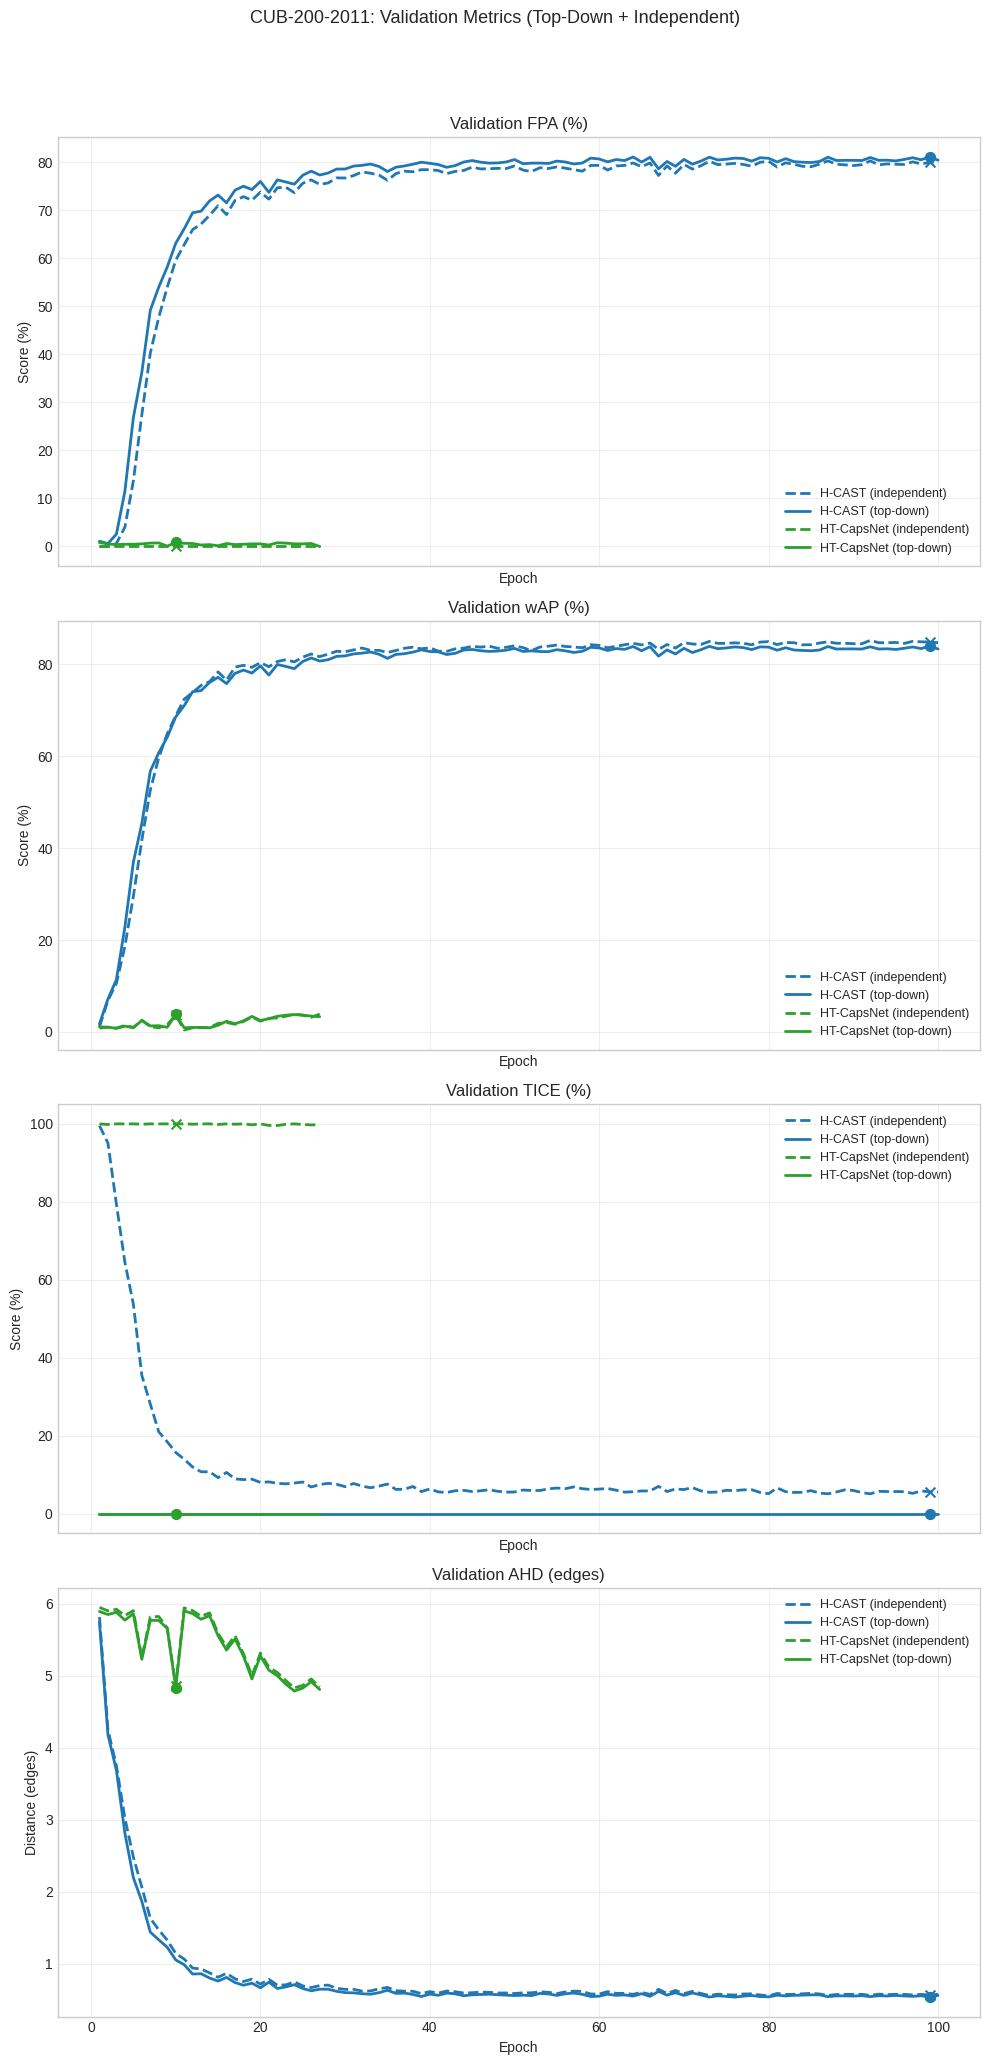

/tmp/ipykernel_1455720/8495700.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


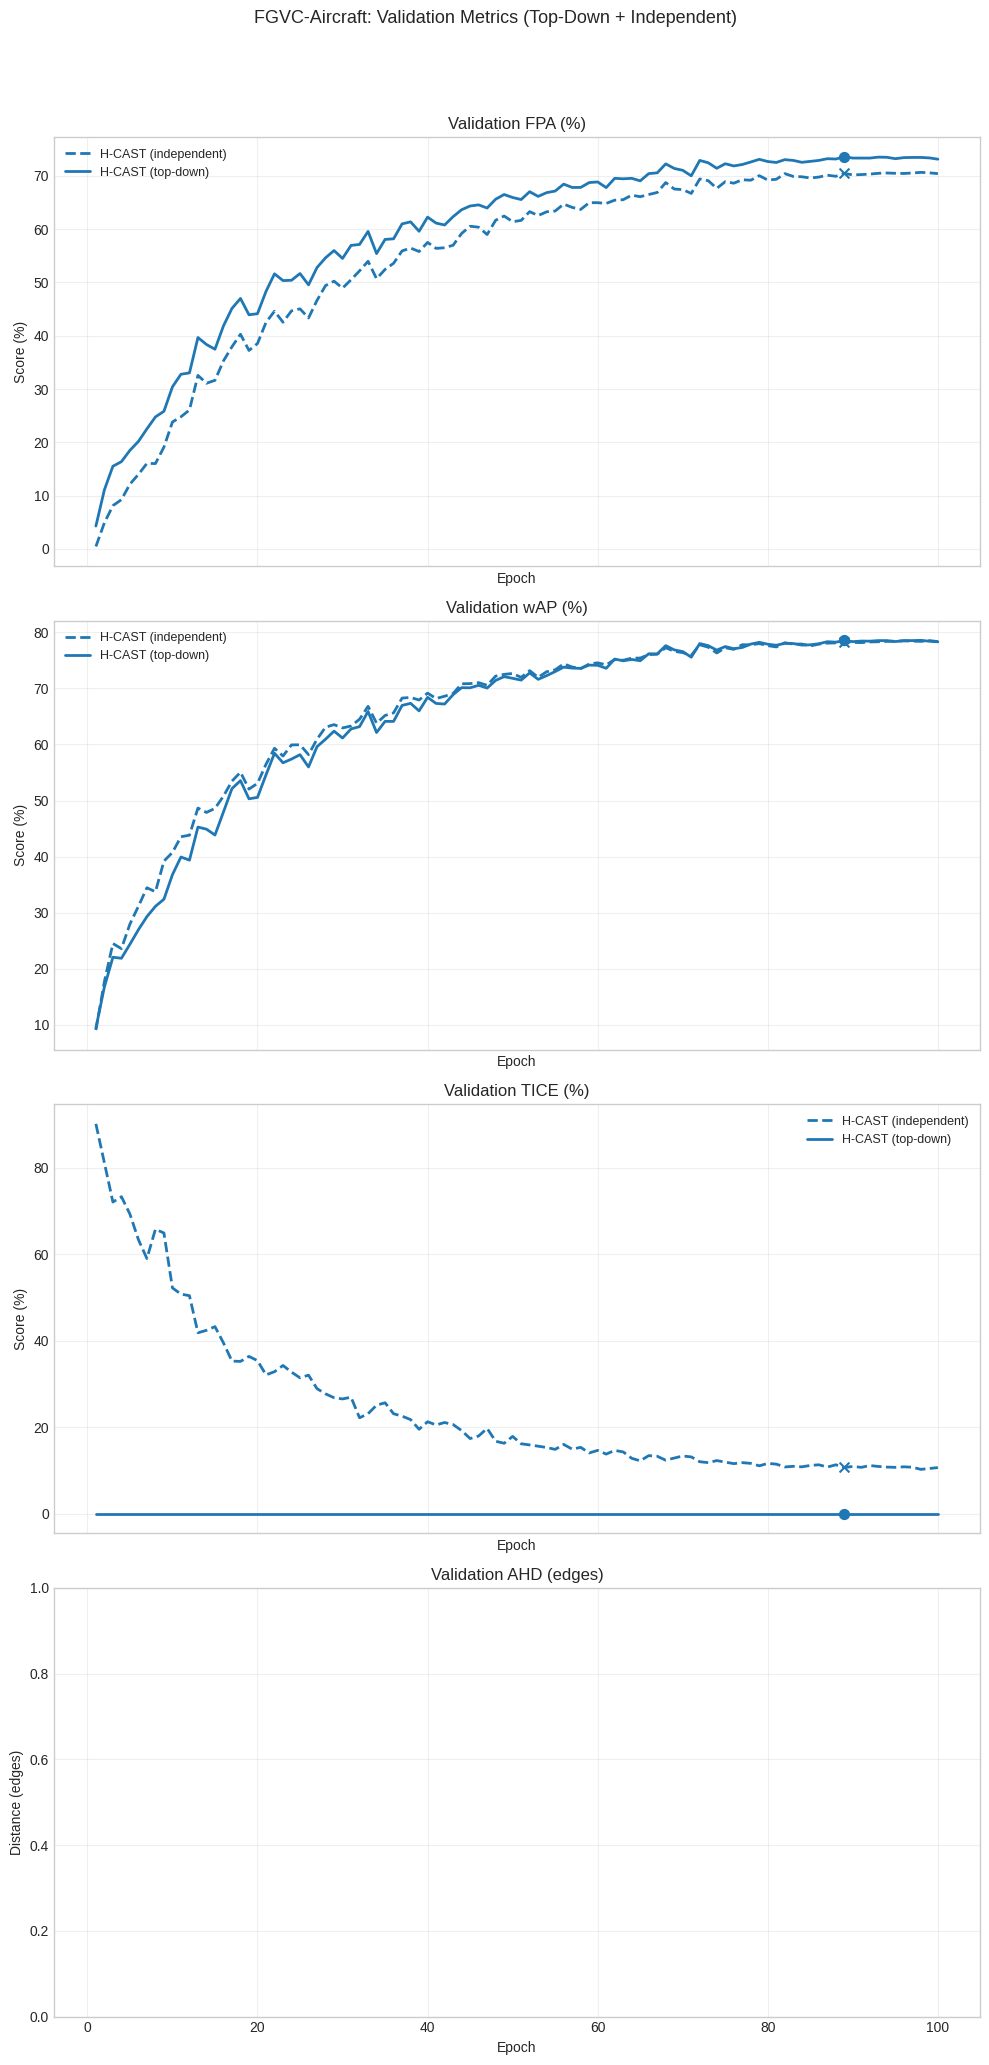

In [60]:
metric_families = [
    ('fpa', 'Validation FPA (%)', True),
    ('weighted_ap', 'Validation wAP (%)', True),
    ('tice', 'Validation TICE (%)', True),
    ('ahd', 'Validation AHD (edges)', False),
]
mode_specs = [
    ('independent', '--', 'independent', 'x'),
    ('topdown', '-', 'top-down', 'o'),
]

for dataset_name in dataset_keys:
    dataset_runs = runs_by_dataset[dataset_name]
    if not dataset_runs:
        continue

    fig, axes = plt.subplots(len(metric_families), 1, figsize=(10, 5 * len(metric_families)), sharex=True)
    if len(metric_families) == 1:
        axes = [axes]
    for ax, (metric_prefix, metric_title, is_percent) in zip(axes, metric_families):
        for run_data in dataset_runs:
            for mode_key, line_style, mode_label, marker in mode_specs:
                metric_key = f'{metric_prefix}_{mode_key}'
                epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
                if np.all(~np.isfinite(values)):
                    continue

                plot_values = values * 100.0 if is_percent else values
                ax.plot(
                    epochs,
                    plot_values,
                    label=f"{run_data['model_label']} ({mode_label})",
                    color=run_data['color'],
                    linestyle=line_style,
                    linewidth=2.0,
                )

                best_event = run_data['best_epoch_event']
                if best_event is not None:
                    best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                    if np.isfinite(best_value):
                        best_plot_value = best_value * 100.0 if is_percent else best_value
                        ax.scatter(
                            [best_event['epoch']],
                            [best_plot_value],
                            color=run_data['color'],
                            marker=marker,
                            s=50,
                            zorder=4,
                        )

        ax.set_title(metric_title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Score (%)' if is_percent else 'Distance (edges)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    plt.suptitle(
        f"{dataset_display_name(dataset_name)}: Validation Metrics (Top-Down + Independent)",
        y=1.03,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()


## Training Loss Comparison (Per Dataset)

Interpretation note:
- Lower is better for all loss curves.

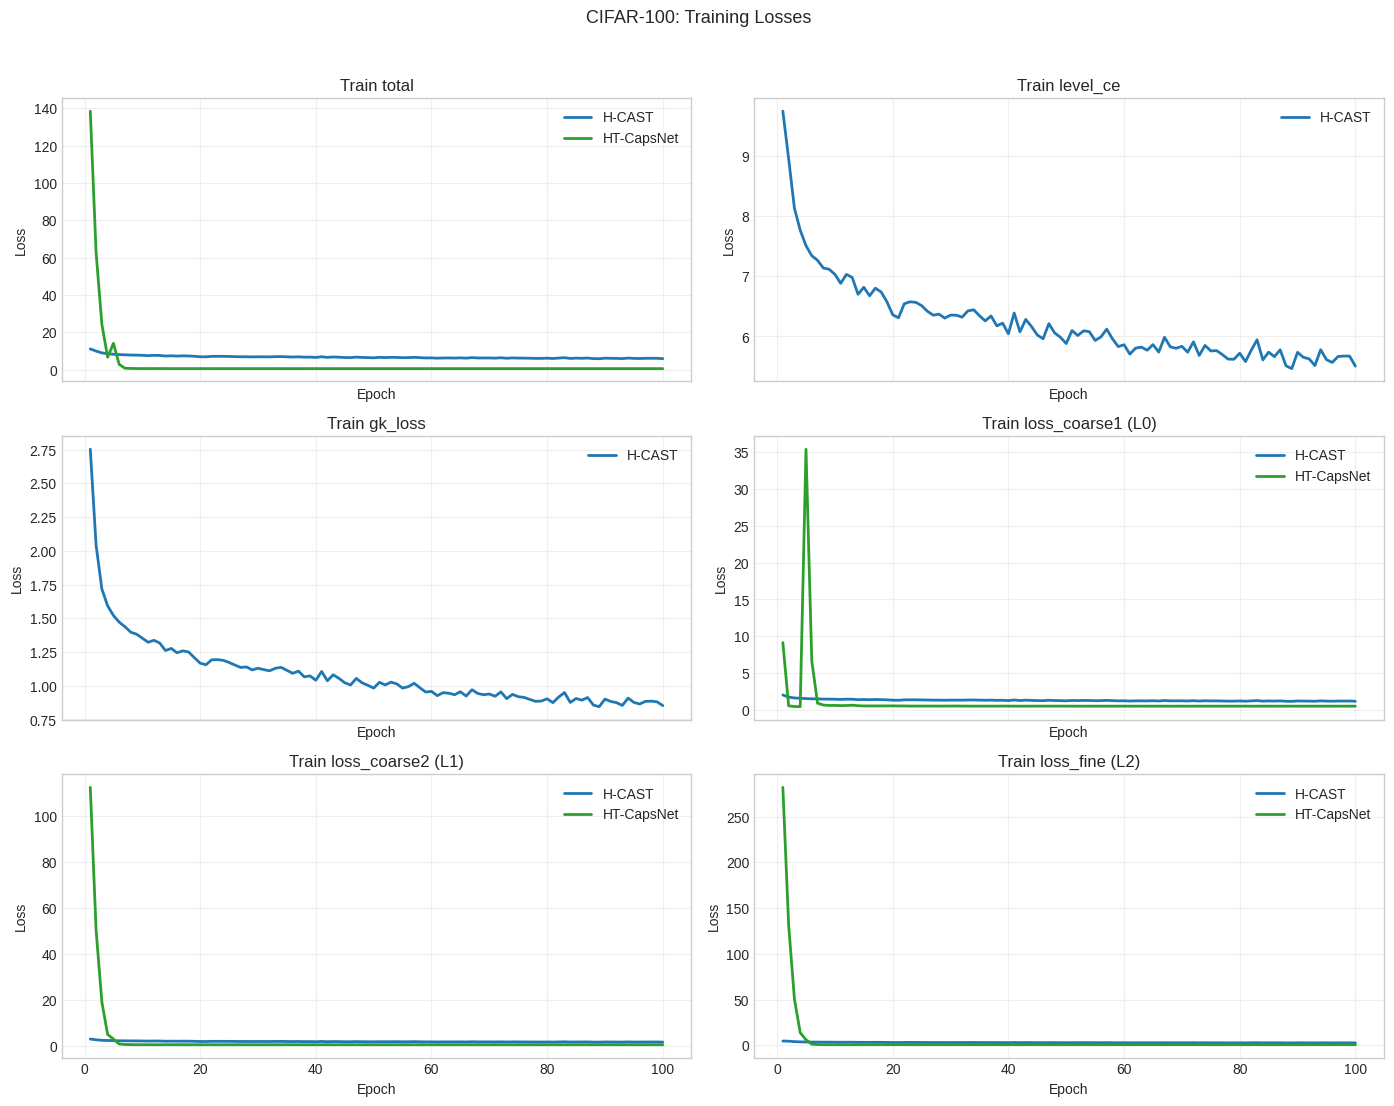

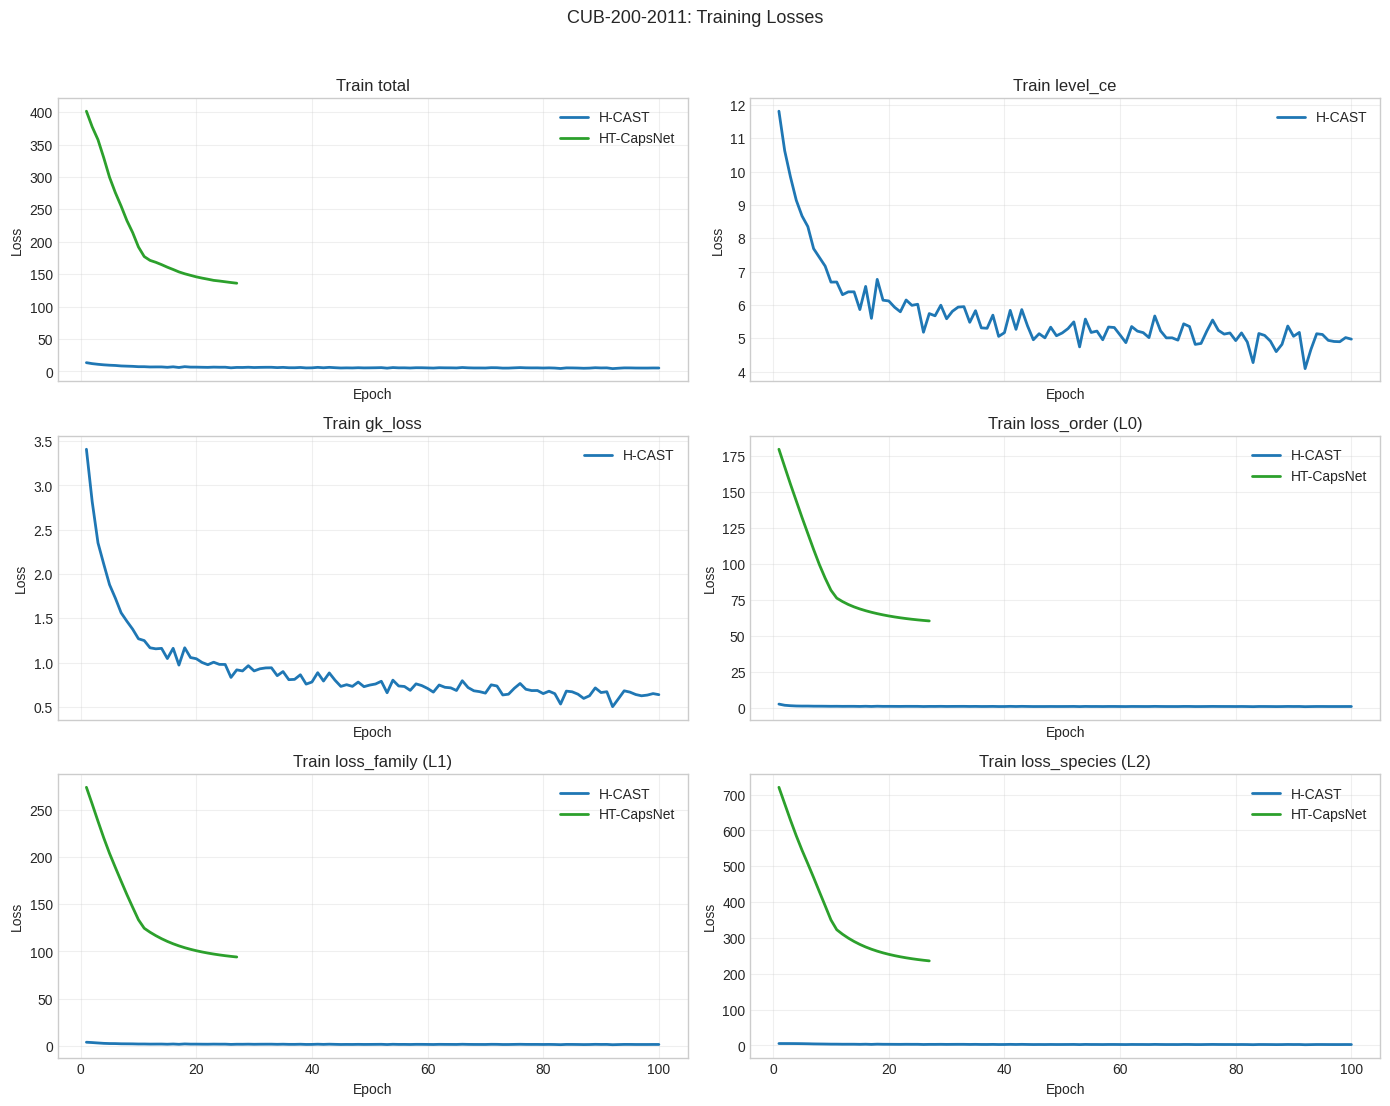

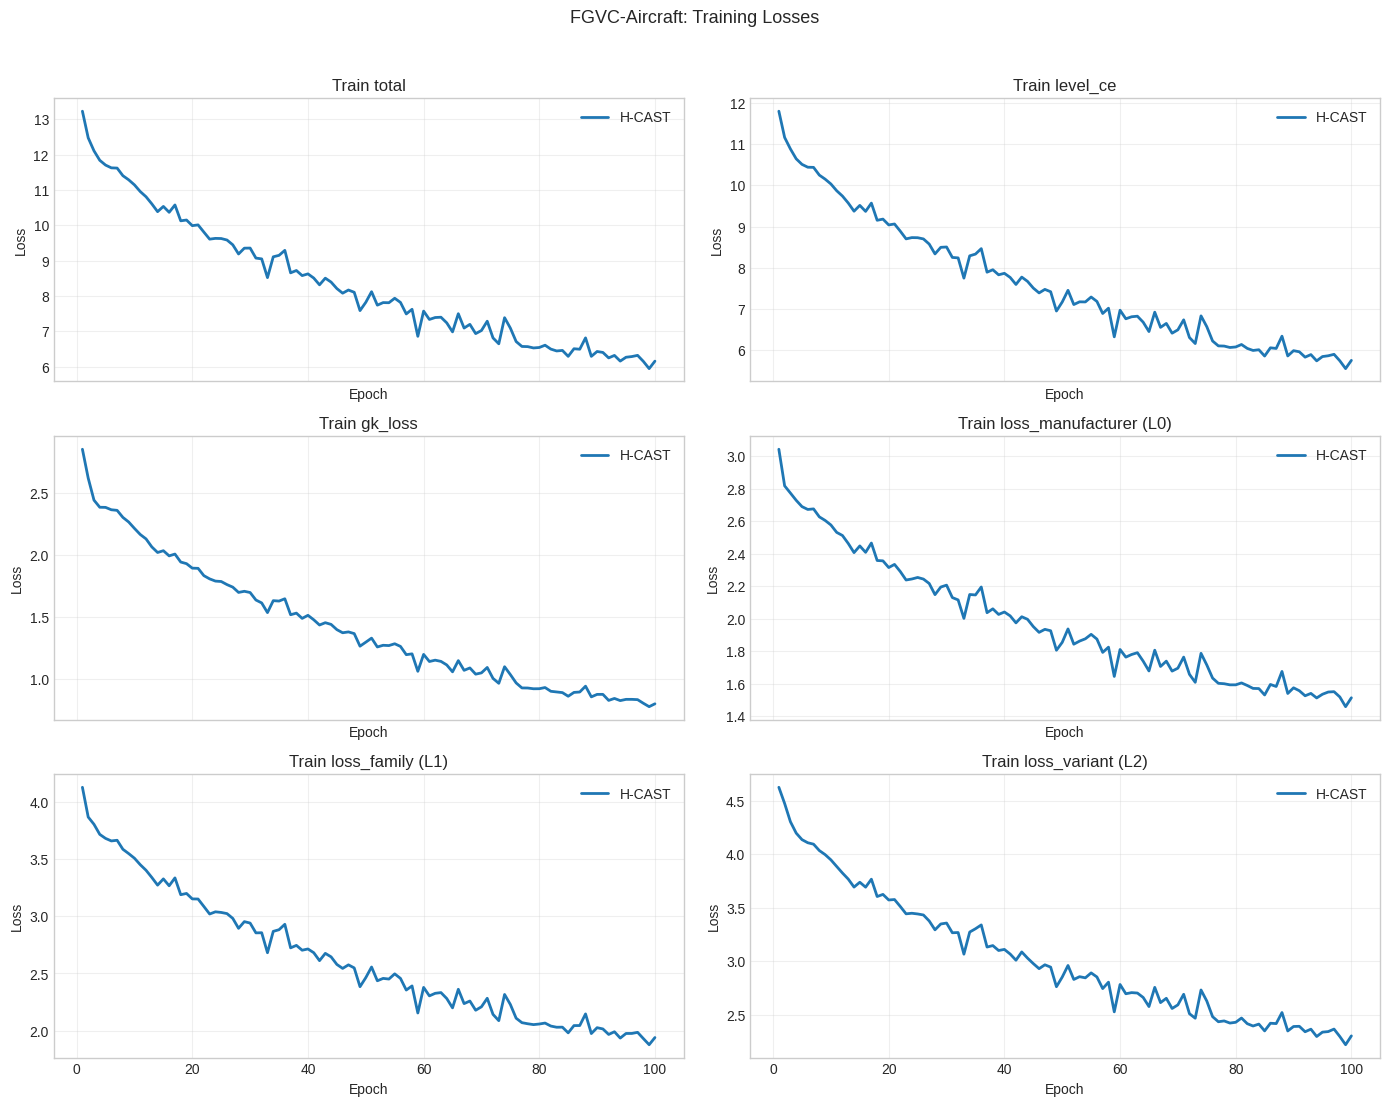

In [61]:
for dataset_name in dataset_keys:
    dataset_runs = runs_by_dataset[dataset_name]
    if not dataset_runs:
        continue

    all_loss_keys = sorted({
        key
        for run_data in dataset_runs
        for event in run_data['epoch_events']
        for key in event.get('train_losses', {}).keys()
    })

    aggregate_loss_keys = [key for key in ['total', 'level_ce', 'gk_loss'] if key in all_loss_keys]
    level_loss_ids = sorted({
        int(match.group(1))
        for key in all_loss_keys
        for match in [_LOSS_LEVEL_PATTERN.match(key)]
        if match is not None
    })

    metric_specs = [(key, key) for key in aggregate_loss_keys]

    base_for_labels = dataset_runs[0]
    for level_idx in level_loss_ids:
        level_name = get_level_label(level_idx, base_for_labels)
        metric_specs.append((f'loss_level_{level_idx}', f'loss_{level_name} (L{level_idx})'))

    if not metric_specs:
        print(f"No train loss keys found for dataset {dataset_display_name(dataset_name)}")
        continue

    n_metrics = len(metric_specs)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, (metric_key, metric_title) in zip(axes, metric_specs):
        for run_data in dataset_runs:
            epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
            if np.all(~np.isfinite(values)):
                continue
            ax.plot(
                epochs,
                values,
                label=run_data['model_label'],
                color=run_data['color'],
                linewidth=2.0,
            )
        ax.set_title(f'Train {metric_title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.legend()

    for ax in axes[n_metrics:]:
        ax.axis('off')

    plt.suptitle(f"{dataset_display_name(dataset_name)}: Training Losses", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

## Training Loss Comparison (Per Model Across Datasets)

Interpretation note:
- This section keeps the model fixed and overlays datasets.
- Only loss keys shared by that model across datasets are plotted.


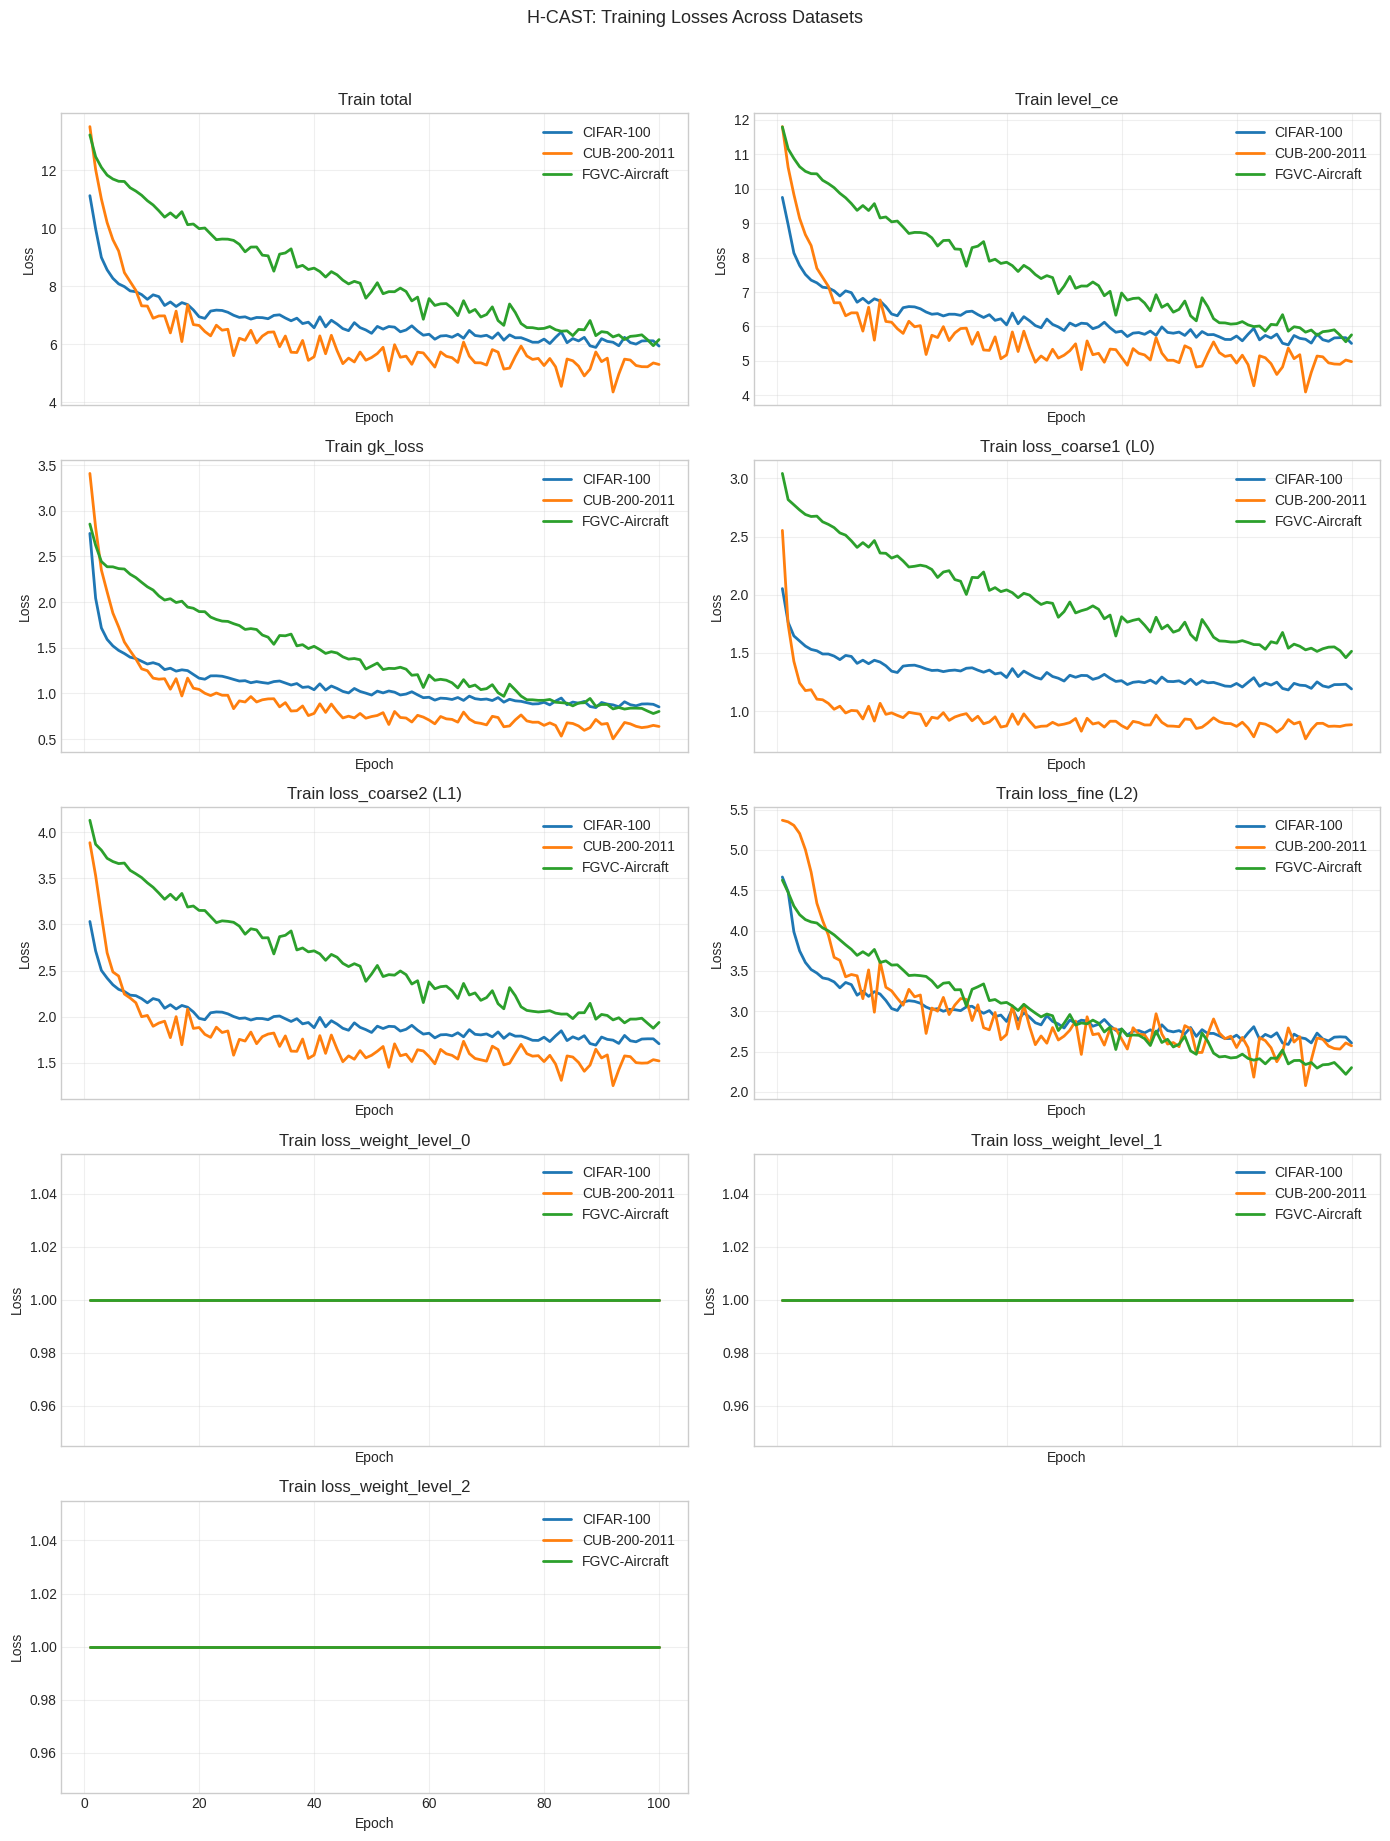

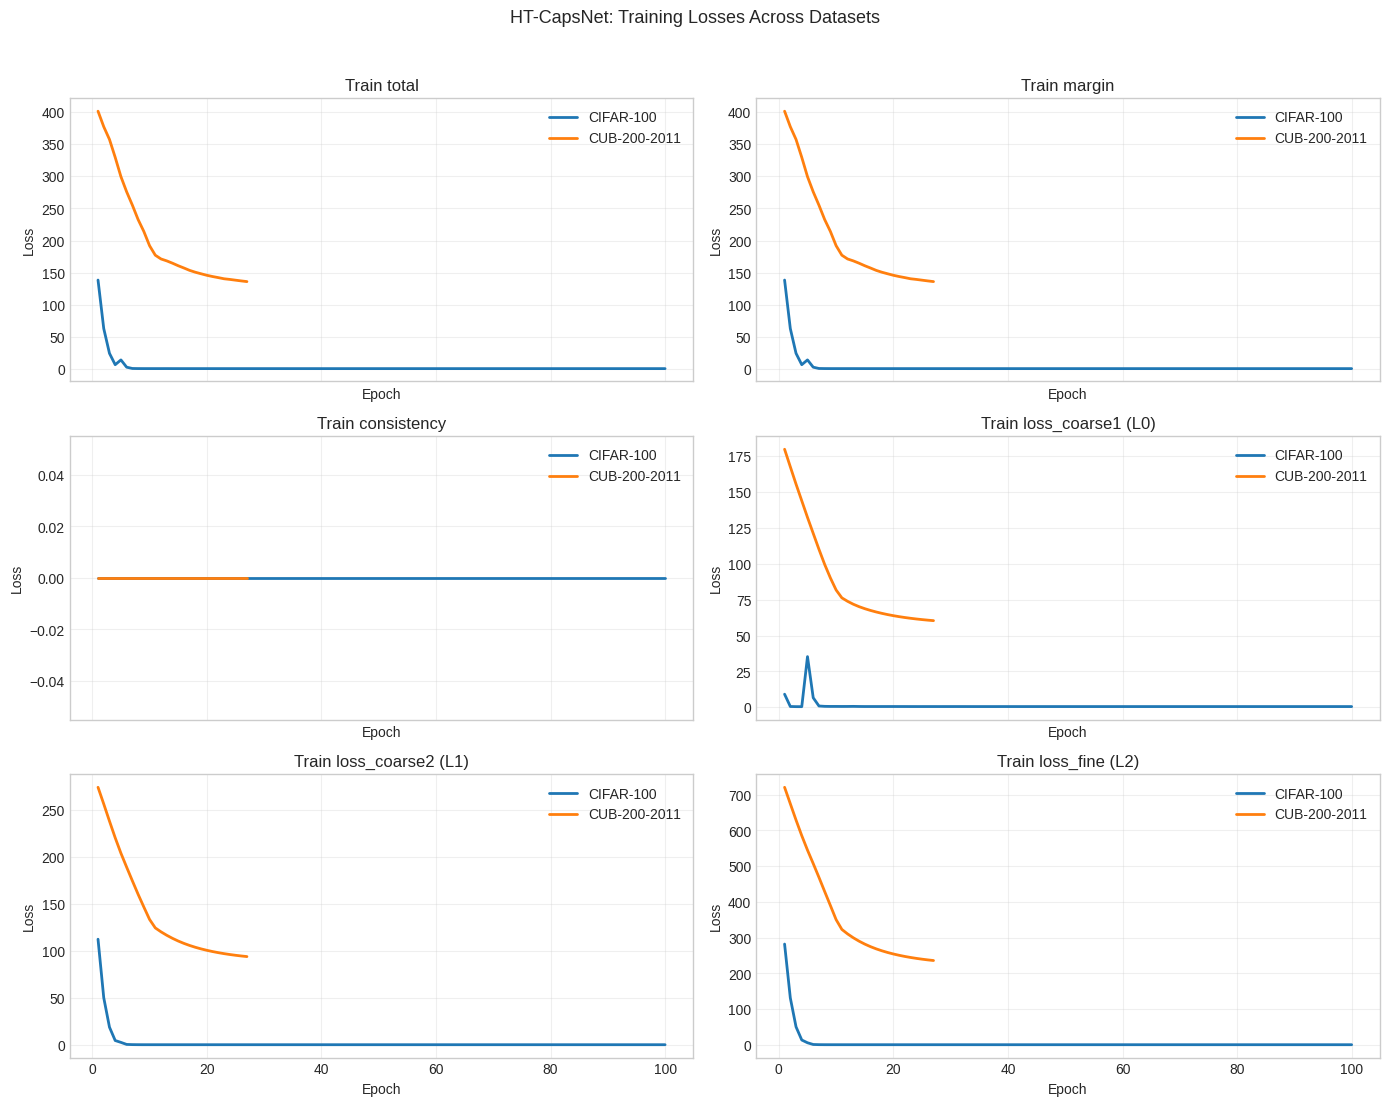

In [62]:
dataset_rank = {name: idx for idx, name in enumerate(dataset_keys)}

runs_by_model = {m: [] for m in model_keys}
for run in runs_for_analysis:
    runs_by_model.setdefault(run['model_name'], []).append(run)

for model_name in model_keys:
    model_runs = runs_by_model.get(model_name, [])
    if not model_runs:
        continue

    model_runs = sorted(
        model_runs,
        key=lambda r: (dataset_rank.get(r['dataset_name'], 999), r['dataset_name'], r['run_name'])
    )

    if len(model_runs) < 2:
        print(f"Skipping {model_display_name(model_name)}: need at least 2 datasets for cross-dataset loss comparison.")
        continue

    loss_keys_per_run = []
    for run_data in model_runs:
        keys = {
            key
            for event in run_data['epoch_events']
            for key in event.get('train_losses', {}).keys()
        }
        if keys:
            loss_keys_per_run.append(keys)

    if not loss_keys_per_run:
        print(f"No training loss keys found for model {model_display_name(model_name)}")
        continue

    shared_loss_keys = set.intersection(*loss_keys_per_run)
    if not shared_loss_keys:
        print(f"No shared train loss keys across datasets for {model_display_name(model_name)}")
        continue

    shared_loss_keys = sorted(shared_loss_keys)

    preferred_aggregate = ['total', 'level_ce', 'gk_loss', 'margin', 'consistency']
    aggregate_loss_keys = [key for key in preferred_aggregate if key in shared_loss_keys]

    level_loss_ids = sorted({
        int(match.group(1))
        for key in shared_loss_keys
        for match in [_LOSS_LEVEL_PATTERN.match(key)]
        if match is not None
    })

    metric_specs = [(key, key) for key in aggregate_loss_keys]

    base_for_labels = model_runs[0]
    for level_idx in level_loss_ids:
        level_name = get_level_label(level_idx, base_for_labels)
        metric_specs.append((f'loss_level_{level_idx}', f'loss_{level_name} (L{level_idx})'))

    used_keys = {key for key, _ in metric_specs}
    other_shared_keys = [key for key in shared_loss_keys if key not in used_keys]
    metric_specs.extend((key, key) for key in other_shared_keys)

    if not metric_specs:
        print(f"No comparable train loss keys for model {model_display_name(model_name)}")
        continue

    n_metrics = len(metric_specs)
    ncols = 2
    nrows = int(np.ceil(n_metrics / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    cmap = plt.get_cmap('tab10')
    dataset_colors = {}
    for idx, run_data in enumerate(model_runs):
        dataset_colors[run_data['dataset_name']] = cmap(idx % 10)

    for ax, (metric_key, metric_title) in zip(axes, metric_specs):
        for run_data in model_runs:
            epochs, values = get_train_loss_series(run_data['epoch_events'], metric_key)
            if np.all(~np.isfinite(values)):
                continue

            ax.plot(
                epochs,
                values,
                label=run_data['dataset_label'],
                color=dataset_colors[run_data['dataset_name']],
                linewidth=2.0,
            )

        ax.set_title(f'Train {metric_title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.legend()

    for ax in axes[n_metrics:]:
        ax.axis('off')

    plt.suptitle(f"{model_display_name(model_name)}: Training Losses Across Datasets", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()



## Per-Level Validation Accuracy (Top-Down and Independent)

Interpretation note:
- Solid vs dashed of the same color shows top-down vs independent for the same model.

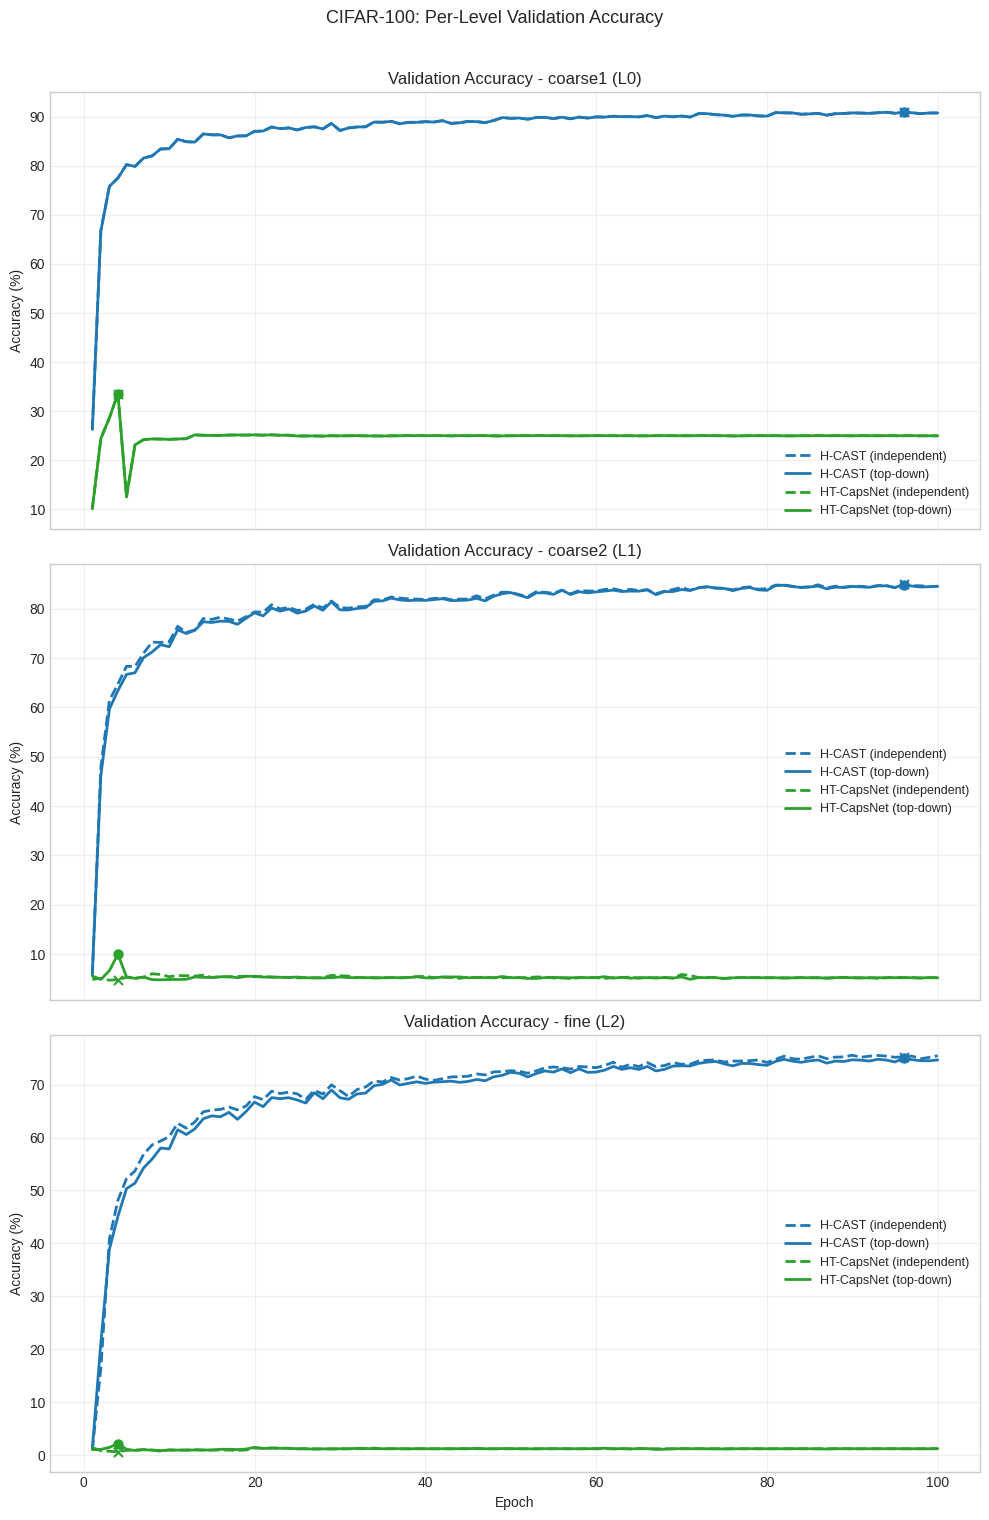

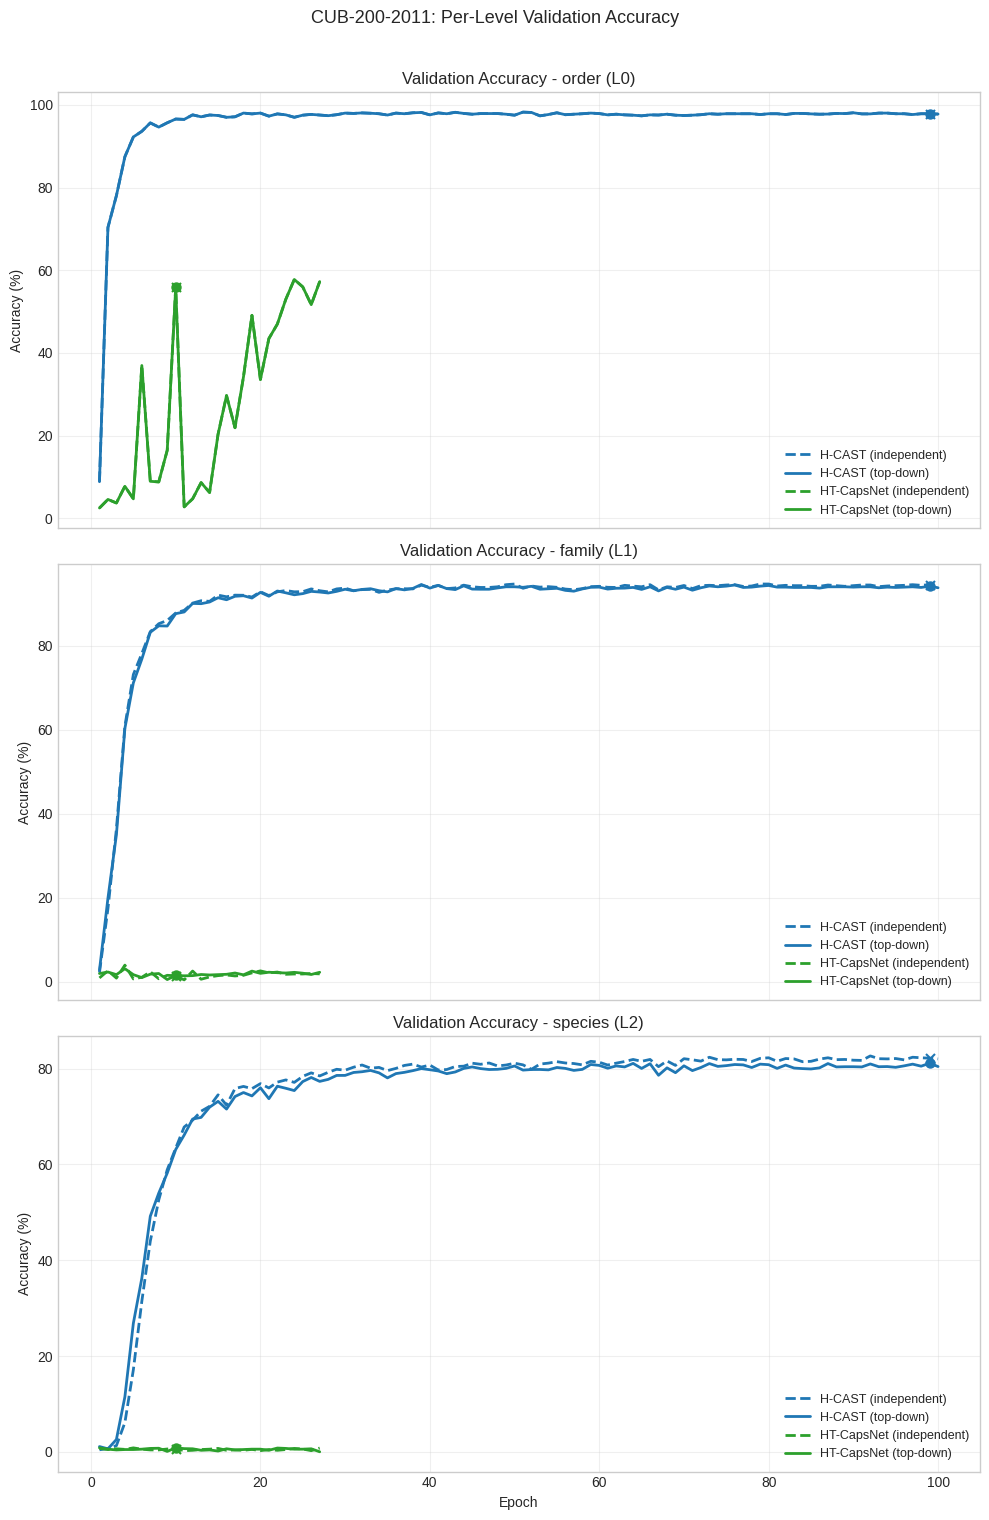

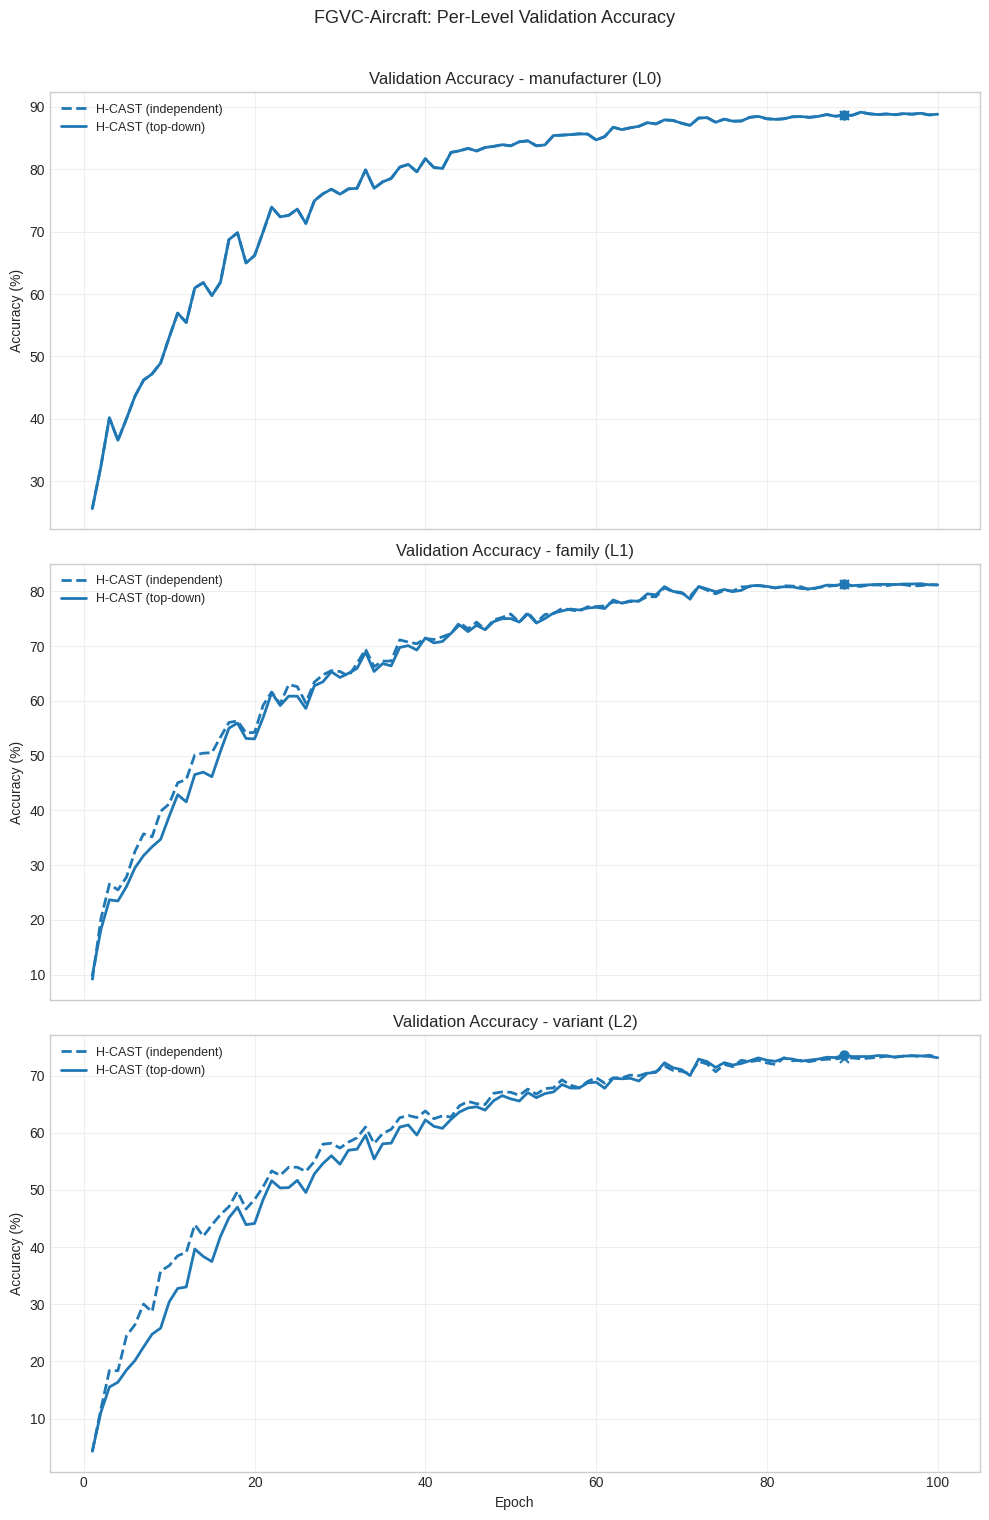

In [63]:
for dataset_name in dataset_keys:
    dataset_runs = runs_by_dataset[dataset_name]
    if not dataset_runs:
        continue

    all_level_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for event in run_data['epoch_events']
        for key in event.get('val_metrics_norm', {}).keys()
        if (
            (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
            and key.rsplit('_', 1)[-1].isdigit()
        )
    })

    if not all_level_ids:
        print(f"No per-level validation accuracy metrics for dataset {dataset_display_name(dataset_name)}")
        continue

    fig, axes = plt.subplots(len(all_level_ids), 1, figsize=(10, 5 * len(all_level_ids)), sharex=True)
    if len(all_level_ids) == 1:
        axes = [axes]

    mode_specs = [
        ('independent', '--', 'independent', 'x'),
        ('topdown', '-', 'top-down', 'o'),
    ]

    for ax, level_idx in zip(axes, all_level_ids):
        for run_data in dataset_runs:
            level_label = get_level_label(level_idx, run_data)
            for mode_key, line_style, mode_label, marker in mode_specs:
                metric_key = f'acc_level_{mode_key}_{level_idx}'
                epochs, values = get_metric_series(run_data['epoch_events'], metric_key)
                if np.all(~np.isfinite(values)):
                    continue
                ax.plot(
                    epochs,
                    values * 100.0,
                    label=f"{run_data['model_label']} ({mode_label})",
                    color=run_data['color'],
                    linestyle=line_style,
                    linewidth=2.0,
                )

                best_event = run_data['best_epoch_event']
                if best_event is not None:
                    best_value = float(best_event['val_metrics_norm'].get(metric_key, np.nan))
                    if np.isfinite(best_value):
                        ax.scatter(
                            [best_event['epoch']],
                            [best_value * 100.0],
                            color=run_data['color'],
                            marker=marker,
                            s=42,
                            zorder=4,
                        )

        ax.set_title(f'Validation Accuracy - {level_label} (L{level_idx})')
        ax.set_ylabel('Accuracy (%)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    axes[-1].set_xlabel('Epoch')
    plt.suptitle(f"{dataset_display_name(dataset_name)}: Per-Level Validation Accuracy", y=1.01, fontsize=13)
    plt.tight_layout()
    plt.show()

## Final Test Comparison Tables (Per Dataset)

The first model in each dataset section is used as baseline for deltas.

In [64]:
metric_rows_base = [
    ('fpa_independent', 'FPA independent'),
    ('fpa_topdown', 'FPA top-down'),
    ('weighted_ap_independent', 'wAP independent'),
    ('weighted_ap_topdown', 'wAP top-down'),
    ('tice_independent', 'TICE independent'),
    ('tice_topdown', 'TICE top-down'),
    ('ahd_independent', 'AHD independent'),
    ('ahd_topdown', 'AHD top-down'),
]

for dataset_name in dataset_keys:
    dataset_runs = runs_by_dataset[dataset_name]
    if not dataset_runs:
        continue

    print('\n' + dataset_display_name(dataset_name))
    print('-' * len(dataset_display_name(dataset_name)))

    if len(dataset_runs) == 1:
        only = dataset_runs[0]
        print(f"Only one model available ({only['model_label']}). Delta columns are skipped.")

    base = dataset_runs[0]
    comparisons = dataset_runs[1:]

    all_level_ids = sorted({
        int(key.rsplit('_', 1)[-1])
        for run_data in dataset_runs
        for key in run_data.get('test_metrics', {}).keys()
        if (
            (key.startswith('acc_level_topdown_') or key.startswith('acc_level_independent_'))
            and key.rsplit('_', 1)[-1].isdigit()
        )
    })

    metric_rows = list(metric_rows_base)
    for level_idx in all_level_ids:
        level_label = get_level_label(level_idx, base)
        metric_rows.append((f'acc_level_independent_{level_idx}', f'Acc independent {level_label} (L{level_idx})'))
        metric_rows.append((f'acc_level_topdown_{level_idx}', f'Acc top-down {level_label} (L{level_idx})'))

    header = f"{'Metric':<40}{base['model_label']:>14}"
    for comp in comparisons:
        header += f"{comp['model_label']:>18}{'Delta vs base':>16}"
    print(header)
    print('-' * len(header))

    for metric_key, metric_name in metric_rows:
        base_value = float(base['test_metrics'].get(metric_key, np.nan))
        is_distance_metric = metric_key.startswith('ahd_')
        base_fmt = fmt_edges(base_value) if is_distance_metric else fmt_pct(base_value)
        row = f"{metric_name:<40}{base_fmt:>14}"
        for comp in comparisons:
            comp_value = float(comp['test_metrics'].get(metric_key, np.nan))
            delta = comp_value - base_value if np.isfinite(base_value) and np.isfinite(comp_value) else np.nan
            comp_fmt = fmt_edges(comp_value) if is_distance_metric else fmt_pct(comp_value)
            delta_fmt = fmt_delta_edges(delta) if is_distance_metric else fmt_delta_pp(delta)
            row += f"{comp_fmt:>18}{delta_fmt:>16}"
        print(row)



CIFAR-100
---------
Metric                                          H-CAST        HT-CapsNet   Delta vs base
----------------------------------------------------------------------------------------
FPA independent                                 71.96%             0.00%       -71.96 pp
FPA top-down                                    73.81%             2.05%       -71.76 pp
wAP independent                                 77.03%             3.35%       -73.68 pp
wAP top-down                                    76.49%             5.24%       -71.25 pp
TICE independent                                 8.38%           100.00%       +91.62 pp
TICE top-down                                    0.00%             0.00%        +0.00 pp
AHD independent                                  1.075               n/a             n/a
AHD top-down                                     1.031               n/a             n/a
Acc independent coarse1 (L0)                    90.29%            33.39%       -56.90 pp


## Quick Summary

In [65]:
for dataset_name in dataset_keys:
    dataset_runs = runs_by_dataset[dataset_name]
    if not dataset_runs:
        continue

    print('\n' + dataset_display_name(dataset_name))
    print('~' * len(dataset_display_name(dataset_name)))

    for run_data in dataset_runs:
        best = run_data['best_epoch_event']
        if best is None:
            print(f"{run_data['model_label']}: no epoch events")
            continue

        best_fpa_ind = best['val_metrics_norm'].get('fpa_independent', np.nan)
        best_fpa_td = best['val_metrics_norm'].get('fpa_topdown', np.nan)
        best_wap_ind = best['val_metrics_norm'].get('weighted_ap_independent', np.nan)
        best_wap_td = best['val_metrics_norm'].get('weighted_ap_topdown', np.nan)
        best_tice_ind = best['val_metrics_norm'].get('tice_independent', np.nan)
        best_tice_td = best['val_metrics_norm'].get('tice_topdown', np.nan)
        best_ahd_ind = best['val_metrics_norm'].get('ahd_independent', np.nan)
        best_ahd_td = best['val_metrics_norm'].get('ahd_topdown', np.nan)

        print(
            f"{run_data['model_label']}: best epoch={best['epoch']}, "
            f"val FPA_ind={100.0 * best_fpa_ind:.2f}%, val FPA_td={100.0 * best_fpa_td:.2f}%, "
            f"val wAP_ind={100.0 * best_wap_ind:.2f}%, val wAP_td={100.0 * best_wap_td:.2f}%, "
            f"val TICE_ind={100.0 * best_tice_ind:.2f}%, val TICE_td={100.0 * best_tice_td:.2f}%, "
            f"val AHD_ind={best_ahd_ind:.3f}, val AHD_td={best_ahd_td:.3f}"
        )

    if len(dataset_runs) < 2:
        continue

    base = dataset_runs[0]
    for comp in dataset_runs[1:]:
        fpa_ind_delta = comp['test_metrics'].get('fpa_independent', np.nan) - base['test_metrics'].get('fpa_independent', np.nan)
        fpa_td_delta = comp['test_metrics'].get('fpa_topdown', np.nan) - base['test_metrics'].get('fpa_topdown', np.nan)
        wap_ind_delta = comp['test_metrics'].get('weighted_ap_independent', np.nan) - base['test_metrics'].get('weighted_ap_independent', np.nan)
        wap_td_delta = comp['test_metrics'].get('weighted_ap_topdown', np.nan) - base['test_metrics'].get('weighted_ap_topdown', np.nan)
        tice_ind_delta = comp['test_metrics'].get('tice_independent', np.nan) - base['test_metrics'].get('tice_independent', np.nan)
        tice_td_delta = comp['test_metrics'].get('tice_topdown', np.nan) - base['test_metrics'].get('tice_topdown', np.nan)
        ahd_ind_delta = comp['test_metrics'].get('ahd_independent', np.nan) - base['test_metrics'].get('ahd_independent', np.nan)
        ahd_td_delta = comp['test_metrics'].get('ahd_topdown', np.nan) - base['test_metrics'].get('ahd_topdown', np.nan)

        print(
            f"Test delta ({comp['model_label']} - {base['model_label']}): "
            f"FPA_ind={100.0 * fpa_ind_delta:+.2f} pp, "
            f"FPA_td={100.0 * fpa_td_delta:+.2f} pp, "
            f"wAP_ind={100.0 * wap_ind_delta:+.2f} pp, "
            f"wAP_td={100.0 * wap_td_delta:+.2f} pp, "
            f"TICE_ind={100.0 * tice_ind_delta:+.2f} pp, "
            f"TICE_td={100.0 * tice_td_delta:+.2f} pp, "
            f"AHD_ind={ahd_ind_delta:+.3f}, "
            f"AHD_td={ahd_td_delta:+.3f}"
        )



CIFAR-100
~~~~~~~~~
H-CAST: best epoch=96, val FPA_ind=72.75%, val FPA_td=74.97%, val wAP_ind=77.76%, val wAP_td=77.52%, val TICE_ind=8.66%, val TICE_td=0.00%, val AHD_ind=1.036, val AHD_td=0.984
HT-CapsNet: best epoch=4, val FPA_ind=0.00%, val FPA_td=2.21%, val wAP_ind=3.37%, val wAP_td=5.38%, val TICE_ind=100.00%, val TICE_td=0.00%, val AHD_ind=nan, val AHD_td=nan
Test delta (HT-CapsNet - H-CAST): FPA_ind=-71.96 pp, FPA_td=-71.76 pp, wAP_ind=-73.68 pp, wAP_td=-71.25 pp, TICE_ind=+91.62 pp, TICE_td=+0.00 pp, AHD_ind=+nan, AHD_td=+nan

CUB-200-2011
~~~~~~~~~~~~
H-CAST: best epoch=99, val FPA_ind=79.98%, val FPA_td=81.15%, val wAP_ind=84.89%, val wAP_td=84.00%, val TICE_ind=5.58%, val TICE_td=0.00%, val AHD_ind=0.563, val AHD_td=0.535
HT-CapsNet: best epoch=10, val FPA_ind=0.00%, val FPA_td=0.84%, val wAP_ind=3.64%, val wAP_td=3.79%, val TICE_ind=100.00%, val TICE_td=0.00%, val AHD_ind=4.861, val AHD_td=4.836
Test delta (HT-CapsNet - H-CAST): FPA_ind=-59.31 pp, FPA_td=-59.74 pp, wAP_in